# AIMS | Physics for Machine Learning | CW1

Hugo Touchette

Started: 23 Oct 2023

Last updated: 1 Nov 2023

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import networkx as nx

## Q1

See the Wikipedia page of each random variable.

##  Q2

Solution 1 using generating functions:
$$
E[e^{ik Z}]= E[e^{ik(X+Y)}] = E[e^{ikX}e^{ikY}]=E[e^{ikX}]E[e^{ikY}],
$$
where the last equality follows from the independence of $X$ and $Y$. For $X$ and $Y$ normal, $E[e^{ikX}] = e^{-k^2/2}$, leading to $E[e^{ik Z}] =e^{-k^2/2}$, and thus $Z\sim\mathcal{N}(0,2)$. This makes sense:
$$
E[X+Y]= E[X]+E[Y]=0
$$
and
$$
\text{var}(X+Y)=\text{var}(X)+\text{var}(Y)=2
$$
for $X$ and $Y$ standard normal.

Repeating for two Gaussians with mean $\mu$ and variance $\sigma^2$, we find $Z\sim\mathcal{N}(2\mu,2\sigma^2)$. For $n$ such Gaussians, we find $Z\sim\mathcal{N}(n\mu,n\sigma^2)$.

Solution 1 using convolutions:
$$
p_Z(z) = \iint\limits_{z=x+y} dx\, dy \, p_{XY}(x,y) = \int_{-\infty}^\infty dx\, p_X(x)p_Y(z-x)
$$
using $p_{XY}(x,y) =p_X(x)p_Y(y)$ because of independence. For two normal random variables, we find by direct integration (by hand or using Mathematica):
$$
p_Z(z) = \int_{-\infty}^\infty dx\, \frac{1}{\sqrt{2\pi}} e^{-x^{2}/2}\,  \frac{1}{\sqrt{2\pi}} e^{-(z-x)^{2}/2} =  \frac{1}{\sqrt{4\pi}} e^{-z^{2}/4},
$$
so again $Z\sim\mathcal{N}(0,2)$.

## Q3

From the transformation formula, seen in class, we get
$$
p_Y(y) = \frac{1}{\sqrt{2\pi \sigma^2} y} \exp\left[-\frac{(\ln y - \mu)^2}{2\sigma^2}\right]
$$
for $y>0$. This is called the log normal distribution.

## Q4

My own histogram function:

In [ ]:
def myhist(data, a, b, n):
    sample_size = len(data)
    dx = (b-a)/float(n)
    h = np.zeros(n, float)
    for i in range(sample_size):
        if data[i] >= a and data[i] <= b:
            pos = int((data[i]-a)/dx)
            h[pos] += 1
    h /= sample_size*dx
    return(h)

Test with a bunch of normal RVs and comparison with the normal pdf (from the stats package):

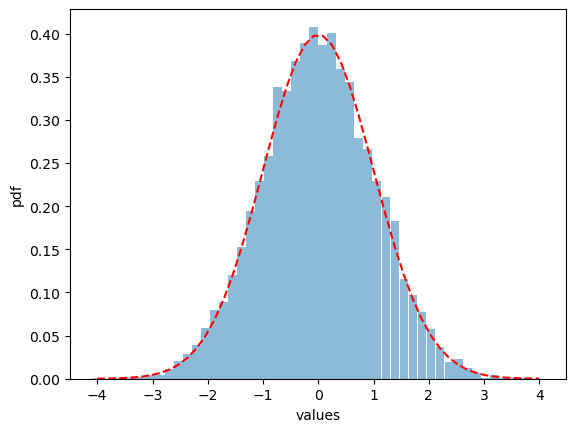

In [ ]:
nsample = 10**4
xmin = -4.0
xmax = 4.0
nbin = 50

data = np.random.randn(nsample)
hval = myhist(data, xmin, xmax, nbin)
centers = np.linspace(xmin, xmax, nbin)

plt.bar(centers, hval, width=(xmax-xmin)/nbin, alpha=0.5)
plt.plot(centers, stats.norm.pdf(centers), 'r--')
plt.xlabel('values')
plt.ylabel('pdf')
plt.show()

## Q5

### (a)

In [ ]:
def randomchoice(states, probs):
    r = np.random.random()
    cdf = 0.0
    n = len(states)
    for i in range(n):
        newcdf = cdf + probs[i]
        if cdf < r <= newcdf:
            return states[i]
        cdf = newcdf

Test on $[1,2,3]$ with probabilities $[0.5, 0.3, 0.2]$:

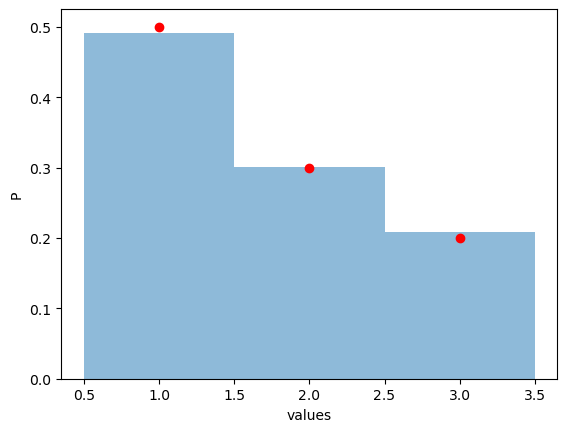

In [ ]:
vals = [1, 2, 3]
probs = [0.5, 0.3, 0.2]
samplesize = 10**4

data = [randomchoice(vals, probs) for i in range(samplesize)]

hist, _ = np.histogram(data, 3)
plt.bar(vals, hist/no_sample, width=1, alpha=0.5)
plt.plot(vals, probs, 'ro')
plt.xlabel('values')
plt.ylabel('P')
plt.show()

### (b)

For $U$ uniform on $[0,1]$, $Y=2U-1$ is uniform on $[-1,1]$.

In [ ]:
def symUnif():
    return 2*np.random.random() - 1.0

Test with $10^4$ variates:

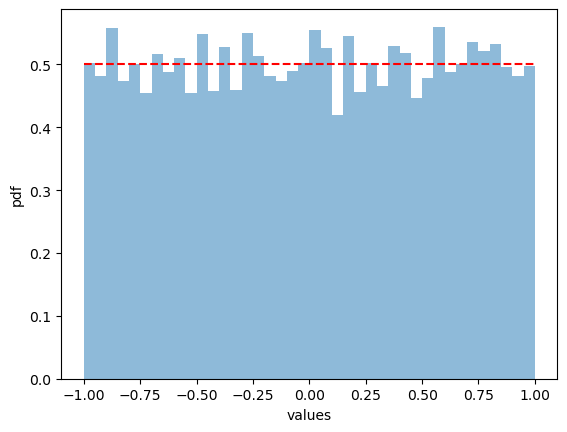

In [ ]:
samplesize = 10**4
xmin = -1.0
xmax = 1.0
nbin = 40

data = [symUnif() for i in range(samplesize)]

# Histogram
centers = np.linspace(xmin, xmax, nbin)
plt.plot(centers, 0.5*np.ones(len(centers)), 'r--')
plt.hist(data, nbin, density=True, alpha=0.5)
plt.xlabel('values')
plt.ylabel('pdf')
plt.show()

### (c)

For the exponential, the transformation, as seen in class, is
$$
X=-\frac{1}{\lambda}\ln(U),
$$
where $U\sim\mathcal{U}[0,1]$.

In [ ]:
def myExpRV(l):
    u = np.random.random()
    return -np.log(u)/l

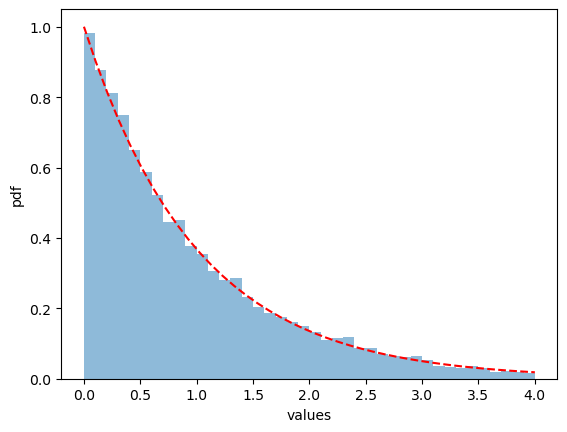

In [ ]:
l = 1.0
samplesize = 10**4
xmin = 0.0
xmax = 4.0
nbin = 40

data = [myExpRV(l) for i in range(samplesize)]

centers = np.linspace(xmin, xmax, nbin)
plt.hist(data, nbin, density=True, alpha=0.5, range=[xmin, xmax])
plt.plot(centers, mylambda*np.exp(-mylambda*centers), 'r--')
plt.xlabel('values')
plt.ylabel('pdf')
plt.show()

## Q6

### (a)

We proceed by sampling a bunch of Gaussian random variables for $X$ and $Y$ and by transforming them:

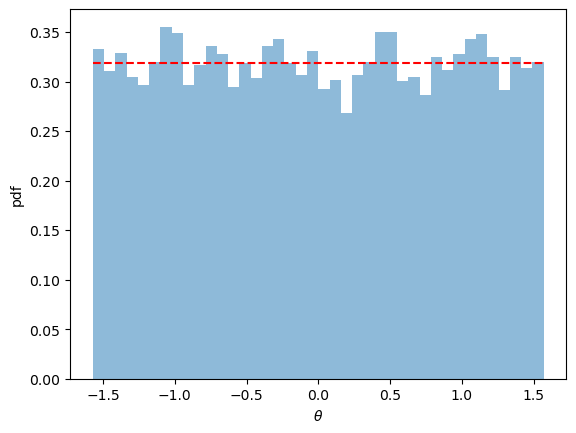

In [ ]:
samplesize = 10**4
nbin = 40

X = [np.random.randn() for i in range(samplesize)]
Y = [np.random.randn() for i in range(samplesize)]

theta = []
for i in range(samplesize):
    theta.append(np.arctan(X[i]/Y[i]))

plt.hist(theta, nbin, density=True, alpha=0.5)
plt.plot([-np.pi/2, np.pi/2], 1/(np.pi)* np.ones(2), 'r--')
plt.xlabel(r'$\theta$')
plt.ylabel('pdf')
plt.show()

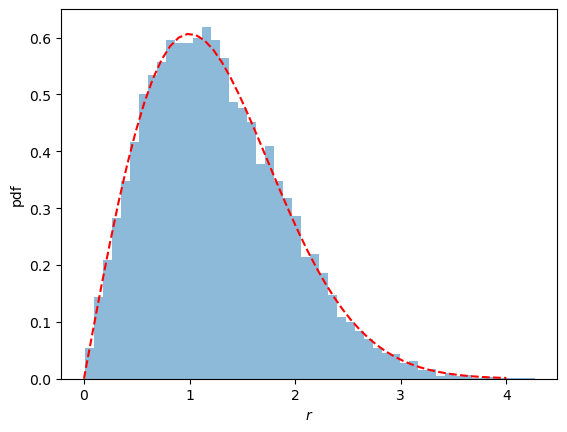

In [ ]:
rmin = 0.0
rmax = 4.0

r = []
for i in range(samplesize):
    r.append(np.sqrt(X[i]**2 + Y[i]**2))

centers = np.linspace(rmin, rmax, nbin)
plt.hist(r, nbin, density=True, alpha=0.5)
plt.plot(centers, [r*np.exp(-r**2/2) for r in centers], 'r--')
plt.xlabel(r'$r$')
plt.ylabel('pdf')
plt.show()

### (b)

Code for the Box-Muller method:

In [ ]:
def BoxMuller(mu, sigma):
    u = np.random.random(2)
    r = np.sqrt(-2.0*np.log(u[0]))
    theta = 2.0*np.pi*u[1]
    return mu+sigma*r*np.cos(theta)

Test with $\mu=\sigma=1$:

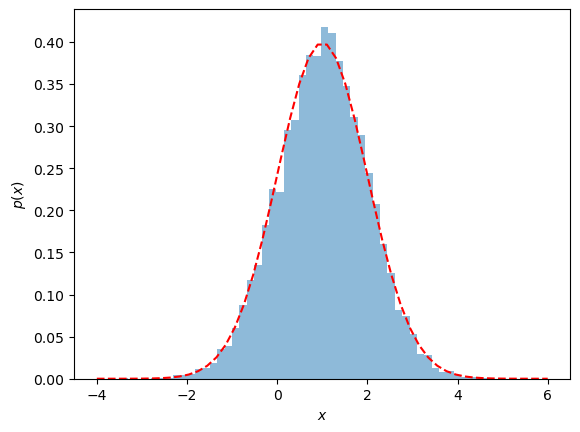

In [ ]:
mu = 1
sigma = 1
nsample = 10**4
xmin = -4.0
xmax = 6.0
nbin = 50

x_sample = [BoxMuller(mu, sigma) for i in range(nsample)]

centers = np.linspace(xmin, xmax, nbin)
hval = plt.hist(x_sample, bins=50, alpha=0.5, density=True)
plt.plot(centers, stats.norm.pdf(centers, loc=mu, scale=sigma), 'r--')
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$');

## Q7

Estimation of the number of points falling in the circle:

In [ ]:
niter = 10**5
pi_est = 0.0
pi_est_sq = 0.0

for i in range(niter):
    # Generate (x, y) in the square
    x = 2.0*np.random.random(2)-1.0
    y = 2.0*np.random.random(2)-1.0

    # Count points in circle
    if x**2+y**2 < 1:
        pi_est += 4.0
        pi_est_sq += 16.0

pi_est /= niter
pi_est_sq /= niter
pi_est_err = np.sqrt(pi_est_sq-pi_est**2)/np.sqrt(niter)
print("pi estimate = ", pi_est, "±", pi_est_err)

pi estimate =  3.14392 ± 0.005187915798854101


Note how the error bar is calculated: the estimator is a sample of $Y_i=4\times 1_{\textrm{circle}}(X_i)$, so
$$
Y_i^2=4^2\times 1_{\textrm{circle}}(X_i)^2= 16\times 1_{\textrm{circle}}(X_i).
$$

Convergence with sample size (including error bars):

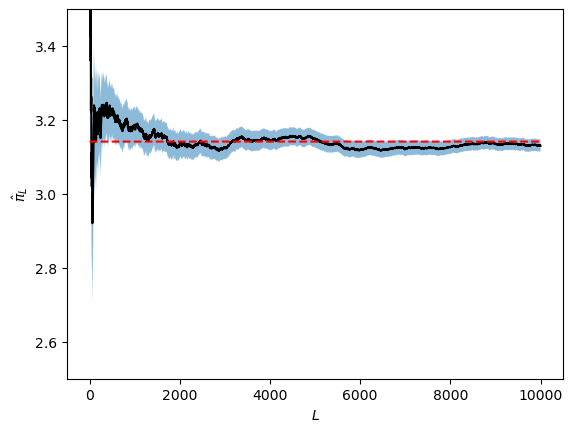

In [ ]:
niter = 10**4
cnt = 0.0

estlist = np.zeros(niter)
errlist = np.zeros(niter)

for i in range(niter):
    x = 2.0*np.random.random()-1.0
    y = 2.0*np.random.random()-1.0
    if x**2+y**2<1:
        cnt += 1.0                # Counter for number of points in circle

    pi_est = 4.0*cnt/(i+1.0)      # pi estimate
    pi_est_sq = 16.0*cnt/(i+1.0)  # Second moment estimate
    estlist[i] = pi_est
    errlist[i] = np.sqrt(pi_est_sq-pi_est**2)/np.sqrt(i+1.0)

plt.plot(range(niter), estlist, 'k-')
plt.fill_between(range(niter), estlist-errlist, estlist+errlist, alpha=0.5)
plt.plot(range(niter), np.zeros(niter)+np.pi, 'r--')
plt.ylim(2.5, 3.5)
plt.xlabel(r'$L$')
plt.ylabel(r'$\hat\pi_L$')
plt.show()

The actual value (in dash) sometimes falls outside the error. That's because we put the $\pm\sigma$ error bar (or confidence interval) which contains 68% of the probability, so there is a 32% chance for the value falling outside.

## Q8

Define a function that generates the dynamics of the Markov chain:

In [ ]:
def MCNextState(x, a, b):
    if x == 0:
        if np.random.random()<a:
            return 1
        else:
            return 0
    else:
        if np.random.random()<b:
            return 0
        else:
            return 1

Here is one simulated trajectory:

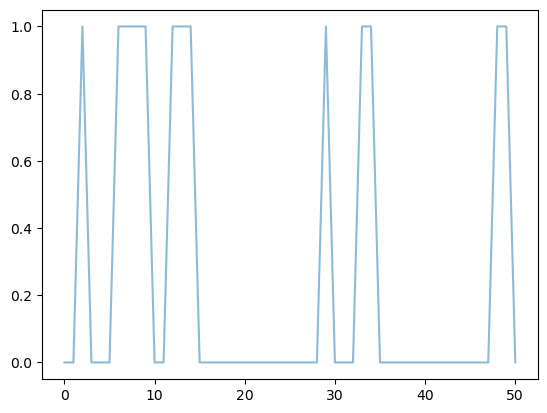

In [ ]:
finaltime = 50
alpha = 0.2
beta = 0.6

x = 0 # Initial condition
traj = [x]
for i in range(finaltime):
    x = MCNextState(x, alpha, beta)
    traj.append(x)

plt.plot(range(finaltime+1), traj, alpha=0.5)
plt.show()

Repeating this for a longer trajectory, we can find the stationary occupancies of the 0 and 1:

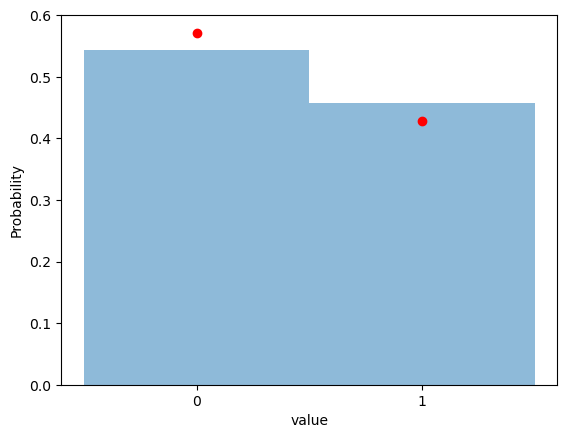

In [ ]:
finaltime = 10**3
alpha = 0.3
beta = 0.4
traj = np.zeros(finaltime, int)

# Simulation
x = 0
for i in range(finaltime):
    x = MCNextState(x, alpha, beta)
    traj[i] = x

# Histogram
hist, bin_spec = np.histogram(traj, bins=[0, 1, 2], density=True)
plt.bar(bin_spec[:-1], hist, width = 1, alpha=0.5)
plt.plot([0, 1], [beta/(alpha+beta), alpha/(alpha+beta)], 'ro')
plt.xticks([0, 1])
plt.xlabel('value')
plt.ylabel('Probability')
plt.show()

## Q9

Python has a nice graph library, called NetworkX (imported above), that we can use to generate and manipulate graphs. The following solution uses that library, but all steps could be also done easily with loops.

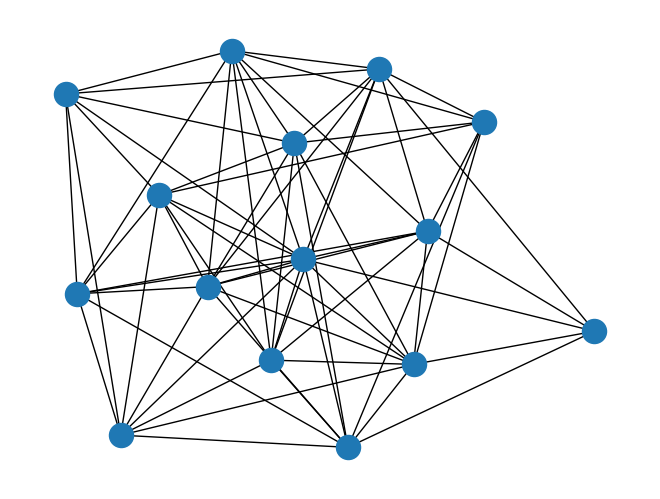

In [ ]:
# Generate a random graph (here a binomial or Erdos-Renyi graph) and show it
nb_nodes = 15
G = nx.binomial_graph(nb_nodes, np.random.random())
nx.draw(G)

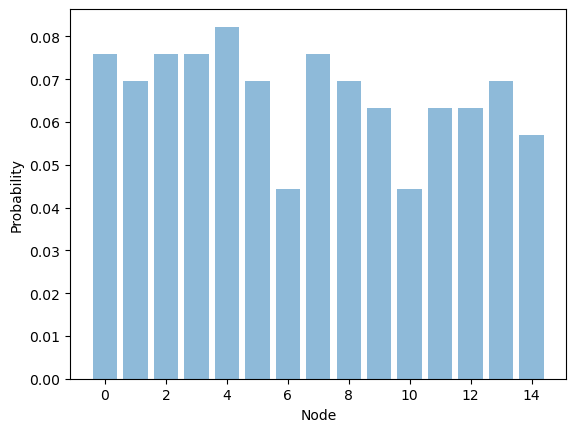

In [ ]:
# List of degrees to compute stationary distribution
degree_list = np.array([val for (node, val) in G.degree()])
p_star = degree_list/sum(degree_list)
plt.bar(range(nb_nodes), p_star, alpha=0.5)
plt.xlabel('Node')
plt.ylabel('Probability')
plt.show()

This bar chart shows the stationary distribution each of the 15 nodes, numbered (in Python) from 0 to 14.

Next is the simulation of the random walk.

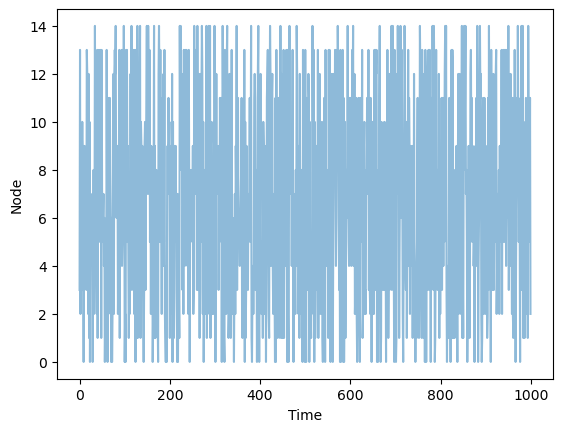

In [ ]:
# Get adjacency matrix (sparse matrix object to be transformed to normal array)
A_sparse = nx.adjacency_matrix(G)
A = A_sparse.toarray()

# Simulation of the random walk on the graph
nb_steps = 10**3
state_list = np.zeros(nb_steps, int)

node = 0
for i in range(nb_steps):
    connected_nodes = np.nonzero(A[node, :])[0]  # Find nodes connected to x
    node = np.random.choice(connected_nodes)   # Choose one of these nodes
    state_list[i] = node                       # Save visited node

# Trajectory
plt.plot(range(nb_steps), state_list, alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Node')
plt.show()

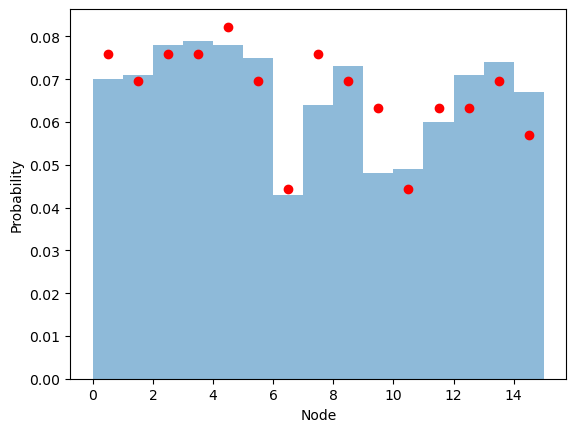

In [ ]:
# Empirical distribution from visited states
plt.hist(state_list, bins=range(nb_nodes+1), density=True, alpha=0.5)
plt.plot(np.arange(nb_nodes)+0.5, p_star, 'ro')
plt.xlabel('Node')
plt.ylabel('Probability')
plt.show()

The bars show the simulation results, compared with the theoretical distribution in red. The results are qualitatively good; better agreement is obtained for longer simulation times, although the convergence is slow. This is known mathematically: the ergodic theorem is slow to converge on random Erdos-Renyi graphs.